# Credit Score & Loan Approval Modeling
This notebook builds **Linear Regression** (target: `credit_score`) and **Logistic Regression** (target: `approved_flag`, binary and multiclass) models using three model families:

1. Plain regression
2. Regularized regression (Ridge / Lasso / ElasticNet-style penalties)
3. Regression trained with different optimizers (Gradient Descent, Momentum, Adam, SAGA)

A single **generic experiment runner** fits/evaluates every combination and appends the results to `results/model_results.csv`, which can be used later for plotting/comparison.

## 1. Imports & Setup

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    SGDRegressor, SGDClassifier, LogisticRegression,
)
from sklearn.neural_network import MLPRegressor, MLPClassifier

from sklearn.metrics import (
    r2_score, mean_absolute_error, root_mean_squared_error,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
RESULTS_CSV = RESULTS_DIR / "model_results.csv"
print(f"Results will be written to: {RESULTS_CSV.resolve()}")

Results will be written to: C:\Users\Kamal\Downloads\results\model_results.csv


## 2. Load Data

In [3]:
df = pd.read_csv("cibil_score.csv")
df = df.drop(columns=["Unnamed: 0"])

# normalize column names
df.columns = [col.lower().strip() for col in df.columns]

print(df.shape)
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
df.head()

(51336, 87)
Duplicate rows: 0


,prospectid,total_tl,tot_closed_tl,tot_active_tl,total_tl_opened_l6m,tot_tl_closed_l6m,pct_tl_open_l6m,pct_tl_closed_l6m,pct_active_tl,pct_closed_tl,...,pct_cc_enq_l6m_of_l12m,pct_pl_enq_l6m_of_ever,pct_cc_enq_l6m_of_ever,max_unsec_exposure_inpct,hl_flag,gl_flag,last_prod_enq2,first_prod_enq2,credit_score,approved_flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [4]:
df["approved_flag"].value_counts()

approved_flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64

## 3. Feature / Target Setup
* `X` -> all columns except `credit_score` and `approved_flag`
* `y_linear` -> `credit_score` (Linear Regression target)
* `y_multiclass` -> `approved_flag` (Logistic Regression, multiclass: P1/P2/P3/P4)
* `y_binary` -> `approved_flag` mapped to **1** for P1/P2 and **0** for P3/P4 (Logistic Regression, binary)

In [5]:
X = df.drop(columns=["approved_flag", "credit_score"])
y_linear = df["credit_score"].astype(float)
y_multiclass = df["approved_flag"].astype(str)

binary_map = {"P1": 1, "P2": 1, "P3": 0, "P4": 0}
y_binary = df["approved_flag"].map(binary_map)

assert y_binary.isna().sum() == 0, "approved_flag has values outside P1-P4"

print(y_multiclass.value_counts())
print(y_binary.value_counts())

approved_flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64
approved_flag
1    38002
0    13334
Name: count, dtype: int64


## 4. Train / Test Split
A single split on `X` is created and then reused (via the shared index) for every target so that every model family sees the exact same rows in train/test.

In [6]:
X_train, X_test, idx_train, idx_test = train_test_split(
    X, X.index, test_size=0.2, random_state=RANDOM_STATE
)

y_linear_train, y_linear_test = y_linear.loc[idx_train], y_linear.loc[idx_test]
y_multi_train, y_multi_test = y_multiclass.loc[idx_train], y_multiclass.loc[idx_test]
y_bin_train, y_bin_test = y_binary.loc[idx_train], y_binary.loc[idx_test]

print(X_train.shape, X_test.shape)

(41068, 85) (10268, 85)


## 5. Missing Value Handling
Domain-specific cleanup carried over/expanded from the original notebook. The dataset encodes several kinds of \"missing\" as the sentinel value `-99999`; the correct treatment depends on what the field means.

In [7]:
# 5a. Drop columns with very high missingness
high_missing = [c for c in ["cc_utilization", "pl_utilization"] if c in X_train.columns]
X_train = X_train.drop(columns=high_missing)
X_test = X_test.drop(columns=high_missing)

# 5b. Median-impute a handful of numeric fields where -99999 means "unknown"
median_columns = [
    "age_oldest_tl", "age_newest_tl", "pct_currentbal_all_tl", "time_since_recent_payment",
]
for col in median_columns:
    if col not in X_train.columns:
        continue
    X_train[col] = X_train[col].replace(-99999, np.nan)
    X_test[col] = X_test[col].replace(-99999, np.nan)
    train_median = X_train[col].median()
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col] = X_test[col].fillna(train_median)  # use TRAIN median to avoid leakage

# 5c. Delinquency fields: -99999 means "never delinquent" -> 0
delinquency_columns = [
    "max_delinquency_level", "max_deliq_6mts", "max_deliq_12mts",
    "time_since_recent_deliquency", "time_since_first_deliquency",
]
delinquency_columns = [c for c in delinquency_columns if c in X_train.columns]
X_train[delinquency_columns] = X_train[delinquency_columns].replace(-99999, 0)
X_test[delinquency_columns] = X_test[delinquency_columns].replace(-99999, 0)

# 5d. Enquiry fields: -99999 means "no enquiry" -> 0
enquiry_columns = [
    "tot_enq", "cc_enq", "pl_enq", "cc_enq_l6m", "cc_enq_l12m",
    "pl_enq_l6m", "pl_enq_l12m", "enq_l3m", "enq_l6m", "enq_l12m",
]
enquiry_columns = [c for c in enquiry_columns if c in X_train.columns]
X_train[enquiry_columns] = X_train[enquiry_columns].replace(-99999, 0)
X_test[enquiry_columns] = X_test[enquiry_columns].replace(-99999, 0)

# 5e. time_since_recent_enq: -99999 = "no enquiry ever" -> longer than any observed gap,
# keep the "no enquiry" signal as its own binary flag (fit on TRAIN only, applied to both)
col = "time_since_recent_enq"
if col in X_train.columns:
    train_mask = X_train[col] == -99999
    test_mask = X_test[col] == -99999
    fill_value = X_train.loc[~train_mask, col].max() + 1

    X_train["no_enquiry_flag"] = train_mask.astype(int)
    X_test["no_enquiry_flag"] = test_mask.astype(int)

    X_train[col] = X_train[col].replace(-99999, fill_value)
    X_test[col] = X_test[col].replace(-99999, fill_value)

# 5f. max_unsec_exposure_inpct: -99999 = "no unsecured loan" -> 0%
col = "max_unsec_exposure_inpct"
if col in X_train.columns:
    X_train[col] = X_train[col].replace(-99999, 0)
    X_test[col] = X_test[col].replace(-99999, 0)

# 5g. Log-transform skewed income
if "netmonthlyincome" in X_train.columns:
    X_train["netmonthlyincome_log"] = np.log1p(X_train["netmonthlyincome"].clip(lower=0))
    X_test["netmonthlyincome_log"] = np.log1p(X_test["netmonthlyincome"].clip(lower=0))
    X_train = X_train.drop(columns=["netmonthlyincome"])
    X_test = X_test.drop(columns=["netmonthlyincome"])

print("Remaining NaNs in X_train:", X_train.isna().sum().sum())
print("Remaining NaNs in X_test:", X_test.isna().sum().sum())

Remaining NaNs in X_train: 0
Remaining NaNs in X_test: 0


## 6. Preprocessing Pipeline (scale numeric, one-hot encode categorical)

In [8]:
numeric_columns = X_train.select_dtypes(include=np.number).columns
categorical_columns = X_train.select_dtypes(include="object").columns
print(f"{len(numeric_columns)} numeric columns, {len(categorical_columns)} categorical columns")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print("Processed shapes:", X_train_processed.shape, X_test_processed.shape)

79 numeric columns, 5 categorical columns
Processed shapes: (41068, 102) (10268, 102)


Processed shapes: (41068, 102) (10268, 102)


In [9]:
X_all_processed = pd.concat([X_train_processed, X_test_processed], axis=0).sort_index()
y_linear_all = y_linear.loc[X_all_processed.index]
y_binary_all = y_binary.loc[X_all_processed.index]
y_multiclass_all = y_multiclass.loc[X_all_processed.index]

In [10]:

def evaluate_regression(model, X_te, y_te):
    y_pred = model.predict(X_te)
    return {
        "r2": r2_score(y_te, y_pred),
        "mae": mean_absolute_error(y_te, y_pred),
        "rmse": root_mean_squared_error(y_te, y_pred),
    }

def evaluate_classification(model, X_te, y_te, binary):
    y_pred = model.predict(X_te)
    metrics = {
        "accuracy": accuracy_score(y_te, y_pred),
        "f1_macro": f1_score(y_te, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_te, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_te, y_pred, average="macro", zero_division=0),
        # Weighted averages
        "precision_weighted": precision_score(
            y_te, y_pred, average="weighted", zero_division=0
        ),
        "recall_weighted": recall_score(
            y_te, y_pred, average="weighted", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_te, y_pred, average="weighted", zero_division=0
        ),

        # Confusion Matrix
        "confusion_matrix": confusion_matrix(y_te, y_pred),

        # Complete classification report
        "classification_report": classification_report(
            y_te,
            y_pred,
            zero_division=0,
            output_dict=True,
        ),
    }
    if binary and hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
        metrics["roc_auc"] = roc_auc_score(y_te, y_prob)
    return metrics

# Linear Regression experiments

In [11]:
N_FOLDS = 5
kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
skfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

CV_RESULTS = []

REGRESSION_SCORING = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
}
CLASSIFICATION_SCORING = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}
BINARY_ONLY_SCORING = {"roc_auc": "roc_auc"}

## Plain Linear Regression

In [12]:
lin_model = LinearRegression()
start = time.time()
lin_model.fit(X_train_processed, y_linear_train)
fit_time = time.time() - start
print(evaluate_regression(lin_model, X_test_processed, y_linear_test))
print(fit_time)

{'r2': 0.910588710512521, 'mae': 5.3181762167038045, 'rmse': 6.1155639468898535}
0.38843464851379395


## Linear Regression with Lasso, Ridge and Elastic

In [13]:
alpha = 0.1
ridge_lin = Ridge(alpha=alpha, random_state=RANDOM_STATE)
start = time.time()
ridge_lin.fit(X_train_processed, y_linear_train)
fit_time = time.time() - start
print(evaluate_regression(ridge_lin, X_test_processed, y_linear_test))
print(fit_time)

{'r2': 0.9105885957898242, 'mae': 5.318180146380621, 'rmse': 6.115567870296881}
0.11745047569274902


In [14]:
alpha = 0.01
lasso_bin = Lasso(alpha=alpha, random_state=RANDOM_STATE, max_iter=5000)
start = time.time()
lasso_bin.fit(X_train_processed, y_linear_train)
fit_time = time.time() - start
print(evaluate_regression(lasso_bin, X_test_processed, y_linear_test))
print(fit_time)

{'r2': 0.9105803708946937, 'mae': 5.319579934067811, 'rmse': 6.115849147322619}
7.372558355331421


In [15]:
alpha = 0.01
l1_ratio = 0.01
elastic_lin = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=RANDOM_STATE, max_iter=5000)
start = time.time()
elastic_lin.fit(X_train_processed, y_linear_train)
fit_time = time.time() - start
print(evaluate_regression(elastic_lin, X_test_processed, y_linear_test))
print(fit_time)

{'r2': 0.9086034584688568, 'mae': 5.363250440799003, 'rmse': 6.183084954296163}
42.861706018447876


## Linear Regression with CV

In [16]:
scoring = dict(REGRESSION_SCORING)
cv = kfold

## Linear Regression with Stratified Fold

In [17]:
from sklearn.model_selection import cross_validate

lin_cv = LinearRegression()

cv_results = cross_validate(
    lin_cv,
    X_all_processed,
    y_linear_all,
    cv=kfold,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    },
    n_jobs=-1
)

print("Mean CV R2 :", cv_results["test_r2"].mean())
print("Mean CV MAE:", -cv_results["test_mae"].mean())
print("Mean CV RMSE:", -cv_results["test_rmse"].mean())

Mean CV R2 : 0.9119094160076825
Mean CV MAE: 5.265654001141451
Mean CV RMSE: 6.0835073561018955


In [18]:
score_bins = pd.qcut(
    y_linear_all,
    q=5,
    labels=False,
    duplicates="drop"
)

In [19]:
from sklearn.model_selection import StratifiedKFold

skf_reg = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

r2_scores = []
mae_scores = []
rmse_scores = []

for train_idx, val_idx in skf_reg.split(X_all_processed, score_bins):

    X_tr = X_all_processed.iloc[train_idx]
    X_val = X_all_processed.iloc[val_idx]

    y_tr = y_linear_all.iloc[train_idx]
    y_val = y_linear_all.iloc[val_idx]

    model = LinearRegression()

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    r2_scores.append(
        r2_score(y_val, y_pred)
    )

    mae_scores.append(
        mean_absolute_error(y_val, y_pred)
    )

    rmse_scores.append(
        root_mean_squared_error(y_val, y_pred)
    )

print("Mean Stratified R2 :", np.mean(r2_scores))
print("Mean Stratified MAE:", np.mean(mae_scores))
print("Mean Stratified RMSE:", np.mean(rmse_scores))

Mean Stratified R2 : 0.9119262742894516
Mean Stratified MAE: 5.265084735415548
Mean Stratified RMSE: 6.082823855447886


## Linear Regression with Grid Search Parameters

In [20]:
from sklearn.model_selection import GridSearchCV

ridge_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_ridge.fit(
    X_train_processed,
    y_linear_train
)

print("Best Parameters:")
print(grid_ridge.best_params_)

print("Best CV R2:")
print(grid_ridge.best_score_)

Best Parameters:
{'alpha': 1}
Best CV R2:
0.9121719958365704


In [21]:
best_ridge = grid_ridge.best_estimator_

y_pred_grid = best_ridge.predict(
    X_test_processed
)

print("Test R2:",
      r2_score(y_linear_test, y_pred_grid))

print("MAE:",
      mean_absolute_error(y_linear_test, y_pred_grid))

print("RMSE:",
      root_mean_squared_error(y_linear_test, y_pred_grid))

Test R2: 0.9105875490143922
MAE: 5.318215487979939
RMSE: 6.115603668904004


## Linear Regression with Random Search Parameters

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

ridge_random = RandomizedSearchCV(
    estimator=Ridge(),

    param_distributions={
        "alpha": loguniform(0.0001, 1000)
    },

    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

ridge_random.fit(
    X_train_processed,
    y_linear_train
)

print("Best Parameters:")
print(ridge_random.best_params_)

print("Best CV R2:")
print(ridge_random.best_score_)

Best Parameters:
{'alpha': np.float64(1.6136341713591311)}
Best CV R2:
0.9121720240734461


In [23]:
best_ridge_random = ridge_random.best_estimator_

y_pred_random = best_ridge_random.predict(
    X_test_processed
)

print("Test R2:",
      r2_score(y_linear_test, y_pred_random))

print("MAE:",
      mean_absolute_error(y_linear_test, y_pred_random))

print("RMSE:",
      root_mean_squared_error(y_linear_test, y_pred_random))

Test R2: 0.9105868206164616
MAE: 5.318240469632976
RMSE: 6.1156285792153495


## Linear Regression with PCA Parameters

In [24]:
from sklearn.decomposition import PCA

In [25]:
pca_reg = PCA(
    n_components=0.95
)

X_train_pca_reg = pca_reg.fit_transform(
    X_train_processed
)

X_test_pca_reg = pca_reg.transform(
    X_test_processed
)

In [26]:
print(
    "Original number of features:",
    X_train_processed.shape[1]
)

print(
    "Number of PCA components:",
    X_train_pca_reg.shape[1]
)

print(
    "Variance retained:",
    pca_reg.explained_variance_ratio_.sum()
)

Original number of features: 102
Number of PCA components: 48
Variance retained: 0.9516727006059014


In [27]:
linear_pca = LinearRegression()

linear_pca.fit(
    X_train_pca_reg,
    y_linear_train
)

y_pred_pca_reg = linear_pca.predict(
    X_test_pca_reg
)

In [28]:
print(
    "PCA Linear Regression R2:",
    r2_score(
        y_linear_test,
        y_pred_pca_reg
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_linear_test,
        y_pred_pca_reg
    )
)

print(
    "RMSE:",
    root_mean_squared_error(
        y_linear_test,
        y_pred_pca_reg
    )
)

PCA Linear Regression R2: 0.8380374520514952
MAE: 6.593046026312801
RMSE: 8.230905825669147


# Logistic regression for Binary classification

### Macro vs Weighted Macro
When should you be concerned?

Case 1: Weighted ≈ Macro ✅

Weighted F1 = 0.91

Macro F1    = 0.89

Interpretation:

Performance is fairly balanced across classes.

The model treats minority and majority classes similarly.

Case 2: Weighted > Macro ⚠️

Weighted F1 = 0.94

Macro F1    = 0.71

Interpretation:

Majority classes are driving the overall performance.

Minority classes are noticeably weaker.

Case 3: Very large gap 🚨

Weighted F1 = 0.97

Macro F1    = 0.42

Interpretation:

The model is likely ignoring one or more minority classes.

Accuracy and weighted metrics alone give a misleadingly optimistic picture.

## Plain and with regularization

In [29]:
lr_bin = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
start = time.time()
lr_bin.fit(X_train_processed, y_bin_train)
fit_time = time.time() - start
print(evaluate_classification(lr_bin, X_test_processed, y_bin_test, binary=True))
print(fit_time)

{'accuracy': 0.892871055707051, 'f1_macro': 0.8569009065256876, 'precision_macro': 0.8776908507064456, 'recall_macro': 0.8412346336221769, 'precision_weighted': 0.8907431946014748, 'recall_weighted': 0.892871055707051, 'f1_weighted': 0.890160018822364, 'confusion_matrix': array([[2010,  744],
       [ 356, 7158]]), 'classification_report': {'0': {'precision': 0.849535080304311, 'recall': 0.7298474945533769, 'f1-score': 0.78515625, 'support': 2754.0}, '1': {'precision': 0.90584662110858, 'recall': 0.9526217726909768, 'f1-score': 0.9286455630513752, 'support': 7514.0}, 'accuracy': 0.892871055707051, 'macro avg': {'precision': 0.8776908507064456, 'recall': 0.8412346336221769, 'f1-score': 0.8569009065256876, 'support': 10268.0}, 'weighted avg': {'precision': 0.8907431946014748, 'recall': 0.892871055707051, 'f1-score': 0.890160018822364, 'support': 10268.0}}, 'roc_auc': 0.9353571227680733}
0.6879005432128906


In [30]:
# l1_ratio = 0.0(l1), 1.0(l2, 0.5(elastic))
C=0.1

lr_bin_reg = LogisticRegression(C=C, l1_ratio=0.0, solver="saga",
                                max_iter=3000, random_state=RANDOM_STATE)
start = time.time()
lr_bin_reg.fit(X_train_processed, y_bin_train)
fit_time = time.time() - start
print(evaluate_classification(lr_bin_reg, X_test_processed, y_bin_test, binary=True))
print(fit_time)

{'accuracy': 0.8920919361121932, 'f1_macro': 0.8557094932434626, 'precision_macro': 0.8769775324392632, 'recall_macro': 0.839782200797195, 'precision_weighted': 0.8899358468274382, 'recall_weighted': 0.8920919361121932, 'f1_weighted': 0.8892976290183188, 'confusion_matrix': array([[2002,  752],
       [ 356, 7158]]), 'classification_report': {'0': {'precision': 0.8490245971162002, 'recall': 0.7269426289034132, 'f1-score': 0.7832550860719875, 'support': 2754.0}, '1': {'precision': 0.9049304677623262, 'recall': 0.9526217726909768, 'f1-score': 0.9281639004149378, 'support': 7514.0}, 'accuracy': 0.8920919361121932, 'macro avg': {'precision': 0.8769775324392632, 'recall': 0.839782200797195, 'f1-score': 0.8557094932434626, 'support': 10268.0}, 'weighted avg': {'precision': 0.8899358468274382, 'recall': 0.8920919361121932, 'f1-score': 0.8892976290183188, 'support': 10268.0}}, 'roc_auc': 0.9350860238810574}
222.8001024723053


In [31]:
# l1_ratio = 0.0(l1), 1.0(l2, 0.5(elastic))
C=1.0

lr_bin_reg = LogisticRegression(C=C, l1_ratio=1.0, solver="saga",
                                max_iter=2000, random_state=RANDOM_STATE)
start = time.time()
lr_bin_reg.fit(X_train_processed, y_bin_train)
fit_time = time.time() - start
print(evaluate_classification(lr_bin_reg, X_test_processed, y_bin_test, binary=True))
print(fit_time)

{'accuracy': 0.8930658356057655, 'f1_macro': 0.857161086695641, 'precision_macro': 0.8779654529610723, 'recall_macro': 0.8414827301793852, 'precision_weighted': 0.890949163472044, 'recall_weighted': 0.8930658356057655, 'f1_weighted': 0.8903597278790507, 'confusion_matrix': array([[2011,  743],
       [ 355, 7159]]), 'classification_report': {'0': {'precision': 0.8499577345731192, 'recall': 0.7302106027596224, 'f1-score': 0.785546875, 'support': 2754.0}, '1': {'precision': 0.9059731713490256, 'recall': 0.9527548575991482, 'f1-score': 0.9287752983912818, 'support': 7514.0}, 'accuracy': 0.8930658356057655, 'macro avg': {'precision': 0.8779654529610723, 'recall': 0.8414827301793852, 'f1-score': 0.857161086695641, 'support': 10268.0}, 'weighted avg': {'precision': 0.890949163472044, 'recall': 0.8930658356057655, 'f1-score': 0.8903597278790507, 'support': 10268.0}}, 'roc_auc': 0.9354276761326087}
348.84121346473694


## Binary classification with CV

In [32]:
lr_binary_cv = LogisticRegression(
    max_iter=3000,
    random_state=42
)

binary_cv_results = cross_validate(
    lr_binary_cv,
    X_all_processed,
    y_binary_all,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)

In [33]:
print(
    "CV Accuracy:",
    binary_cv_results["test_accuracy"].mean()
)

print(
    "CV Precision:",
    binary_cv_results["test_precision"].mean()
)

print(
    "CV Recall:",
    binary_cv_results["test_recall"].mean()
)

print(
    "CV F1:",
    binary_cv_results["test_f1"].mean()
)

print(
    "CV ROC-AUC:",
    binary_cv_results["test_roc_auc"].mean()
)

CV Accuracy: 0.8929016699393054
CV Precision: 0.9110286700387513
CV Recall: 0.9479767066660203
CV F1: 0.9291033542338619
CV ROC-AUC: 0.9311715025447256


## Binary classification with Stratified fold

In [34]:
binary_skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [35]:
stratified_binary_results = cross_validate(
    LogisticRegression(
        max_iter=3000,
        random_state=42
    ),

    X_all_processed,
    y_binary_all,

    cv=binary_skf,

    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },

    n_jobs=-1
)

In [36]:
print(
    "Stratified Accuracy:",
    stratified_binary_results["test_accuracy"].mean()
)

print(
    "Stratified Precision:",
    stratified_binary_results["test_precision"].mean()
)

print(
    "Stratified Recall:",
    stratified_binary_results["test_recall"].mean()
)

print(
    "Stratified F1:",
    stratified_binary_results["test_f1"].mean()
)

print(
    "Stratified ROC-AUC:",
    stratified_binary_results["test_roc_auc"].mean()
)

Stratified Accuracy: 0.8931354968807328
Stratified Precision: 0.9099431829820069
Stratified Recall: 0.9496342967338093
Stratified F1: 0.9293615773447794
Stratified ROC-AUC: 0.9313533841969435


## Binary classification with Grid Search Parameters

In [37]:
binary_logistic = LogisticRegression(
    solver="saga",
    max_iter=5000,
    random_state=42
)

binary_grid = {
    "C": [0.01, 0.1, 1, 10, 100],

    "penalty": [
        "l1",
        "l2"
    ],

    "class_weight": [
        None,
        "balanced"
    ]
}

In [ ]:
grid_binary = GridSearchCV(
    estimator=binary_logistic,
    param_grid=binary_grid,
    cv=binary_skf,
    scoring="f1",
    n_jobs=-1
)

grid_binary.fit(
    X_train_processed,
    y_bin_train
)

In [ ]:
print(
    "Best parameters:",
    grid_binary.best_params_
)

print(
    "Best CV F1:",
    grid_binary.best_score_
)

In [ ]:
best_binary_grid = grid_binary.best_estimator_

binary_grid_pred = best_binary_grid.predict(
    X_test_processed
)

binary_grid_prob = best_binary_grid.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
print(
    "Accuracy:",
    accuracy_score(
        y_bin_test,
        binary_grid_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_bin_test,
        binary_grid_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_bin_test,
        binary_grid_pred
    )
)

print(
    "F1:",
    f1_score(
        y_bin_test,
        binary_grid_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_bin_test,
        binary_grid_prob
    )
)

## Binary classification with Random Search Parameters

In [38]:
binary_random = RandomizedSearchCV(
    estimator=LogisticRegression(
        solver="saga",
        max_iter=5000,
        random_state=42
    ),

    param_distributions={
        "C": loguniform(0.001, 100),

        "penalty": [
            "l1",
            "l2"
        ],

        "class_weight": [
            None,
            "balanced"
        ]
    },

    n_iter=20,
    cv=binary_skf,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

In [ ]:
binary_random.fit(
    X_train_processed,
    y_bin_train
)

In [ ]:
print(
    "Best parameters:",
    binary_random.best_params_
)

print(
    "Best CV F1:",
    binary_random.best_score_
)

## Binary classification with PCA Parameters

In [ ]:
pca_binary = PCA(
    n_components=0.95
)

X_train_pca_binary = pca_binary.fit_transform(
    X_train_processed
)

X_test_pca_binary = pca_binary.transform(
    X_test_processed
)

In [ ]:
print(
    "Original features:",
    X_train_processed.shape[1]
)

print(
    "PCA features:",
    X_train_pca_binary.shape[1]
)

print(
    "Variance retained:",
    pca_binary.explained_variance_ratio_.sum()
)

In [ ]:
binary_pca_pred = lr_binary_pca.predict(
    X_test_pca_binary
)

binary_pca_prob = lr_binary_pca.predict_proba(
    X_test_pca_binary
)[:, 1]

In [ ]:
print(
    "Accuracy:",
    accuracy_score(
        y_bin_test,
        binary_pca_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_bin_test,
        binary_pca_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_bin_test,
        binary_pca_pred
    )
)

print(
    "F1:",
    f1_score(
        y_bin_test,
        binary_pca_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_bin_test,
        binary_pca_prob
    )
)

## Plain and Multi class Classification

In [ ]:
lr_multi = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
start = time.time()
lr_multi.fit(X_train_processed, y_multi_train)
fit_time = time.time() - start
print(evaluate_classification(lr_multi, X_test_processed, y_multi_test, binary=False))
print(fit_time)

{'accuracy': 0.8031749123490456, 'f1_macro': 0.7074751665114525, 'precision_macro': 0.735032755561696, 'recall_macro': 0.6932054349254672, 'precision_weighted': 0.7804983731013764, 'recall_weighted': 0.8031749123490456, 'f1_weighted': 0.7867134636337132, 'confusion_matrix': array([[ 897,  238,    0,    0],
       [ 132, 5990,  244,   13],
       [  26,  833,  430,  247],
       [   0,   36,  252,  930]]), 'classification_report': {'P1': {'precision': 0.8502369668246446, 'recall': 0.7903083700440529, 'f1-score': 0.8191780821917808, 'support': 1135.0}, 'P2': {'precision': 0.8440185994082007, 'recall': 0.9390186549615928, 'f1-score': 0.8889878302166815, 'support': 6379.0}, 'P3': {'precision': 0.46436285097192226, 'recall': 0.2799479166666667, 'f1-score': 0.34930950446791226, 'support': 1536.0}, 'P4': {'precision': 0.7815126050420168, 'recall': 0.7635467980295566, 'f1-score': 0.7724252491694352, 'support': 1218.0}, 'accuracy': 0.8031749123490456, 'macro avg': {'precision': 0.73503275556169

In [51]:
# l1_ratio = 0.0(l1), 1.0(l2, 0.5(elastic))
C=0.1

lr_multi_reg = LogisticRegression(C=C, l1_ratio=0.0, solver="saga",
                                max_iter=3000, random_state=RANDOM_STATE)
start = time.time()
lr_multi_reg.fit(X_train_processed, y_multi_train)
fit_time = time.time() - start
print(evaluate_classification(lr_multi_reg, X_test_processed, y_multi_test, binary=False))
print(fit_time)

{'accuracy': 0.8002532138683288, 'f1_macro': 0.6996298476674592, 'precision_macro': 0.7325777346715552, 'recall_macro': 0.6838151367357044, 'precision_weighted': 0.7750912794052883, 'recall_weighted': 0.8002532138683288, 'f1_weighted': 0.7810879265425021, 'confusion_matrix': array([[ 881,  254,    0,    0],
       [ 129, 6018,  222,   10],
       [  26,  876,  391,  243],
       [   0,   51,  240,  927]]), 'classification_report': {'P1': {'precision': 0.8503861003861004, 'recall': 0.7762114537444934, 'f1-score': 0.8116075541225242, 'support': 1135.0}, 'P2': {'precision': 0.8359494374218641, 'recall': 0.943408057689293, 'f1-score': 0.8864339372514362, 'support': 6379.0}, 'P3': {'precision': 0.45838218053927315, 'recall': 0.2545572916666667, 'f1-score': 0.3273336123901214, 'support': 1536.0}, 'P4': {'precision': 0.785593220338983, 'recall': 0.7610837438423645, 'f1-score': 0.7731442869057548, 'support': 1218.0}, 'accuracy': 0.8002532138683288, 'macro avg': {'precision': 0.7325777346715552

In [52]:
# l1_ratio = 0.0(l1), 1.0(l2, 0.5(elastic))
C=10

lr_multi_reg = LogisticRegression(C=C, l1_ratio=0.0, solver="saga",
                                max_iter=3000, random_state=RANDOM_STATE)
start = time.time()
lr_multi_reg.fit(X_train_processed, y_multi_train)
fit_time = time.time() - start
print(evaluate_classification(lr_multi_reg, X_test_processed, y_multi_test, binary=False))
print(fit_time)

{'accuracy': 0.8030775223996883, 'f1_macro': 0.7073440868587433, 'precision_macro': 0.7354241473415939, 'recall_macro': 0.6926955378675866, 'precision_weighted': 0.7803466602109494, 'recall_weighted': 0.8030775223996883, 'f1_weighted': 0.7865232459850605, 'confusion_matrix': array([[ 896,  239,    0,    0],
       [ 132, 5992,  244,   11],
       [  26,  836,  429,  245],
       [   0,   38,  251,  929]]), 'classification_report': {'P1': {'precision': 0.8500948766603416, 'recall': 0.7894273127753304, 'f1-score': 0.8186386477843764, 'support': 1135.0}, 'P2': {'precision': 0.8433497536945813, 'recall': 0.939332183727857, 'f1-score': 0.8887570453871255, 'support': 6379.0}, 'P3': {'precision': 0.4642857142857143, 'recall': 0.279296875, 'f1-score': 0.348780487804878, 'support': 1536.0}, 'P4': {'precision': 0.7839662447257384, 'recall': 0.7627257799671593, 'f1-score': 0.7732001664585935, 'support': 1218.0}, 'accuracy': 0.8030775223996883, 'macro avg': {'precision': 0.7354241473415939, 'recal

In [17]:
# l1_ratio = 0.0(l1), 1.0(l2, 0.5(elastic))
C=10

lr_multi_reg = LogisticRegression(C=C, l1_ratio=1.0, solver="saga",
                                max_iter=2000, random_state=RANDOM_STATE)
start = time.time()
lr_multi_reg.fit(X_train_processed, y_multi_train)
fit_time = time.time() - start
print(evaluate_classification(lr_multi_reg, X_test_processed, y_multi_test, binary=False))
print(fit_time)

{'accuracy': 0.802493182703545, 'f1_macro': 0.7058207039932964, 'precision_macro': 0.7353354018966146, 'recall_macro': 0.6905239765198988, 'precision_weighted': 0.7793466830013531, 'recall_weighted': 0.802493182703545, 'f1_weighted': 0.7854280525925812, 'confusion_matrix': array([[ 891,  244,    0,    0],
       [ 130, 5999,  241,    9],
       [  26,  843,  422,  245],
       [   0,   43,  247,  928]]), 'classification_report': {'P1': {'precision': 0.8510028653295129, 'recall': 0.785022026431718, 'f1-score': 0.8166819431714024, 'support': 1135.0}, 'P2': {'precision': 0.8414924954411559, 'recall': 0.940429534409782, 'f1-score': 0.8882143914717204, 'support': 6379.0}, 'P3': {'precision': 0.46373626373626375, 'recall': 0.2747395833333333, 'f1-score': 0.34505314799672937, 'support': 1536.0}, 'P4': {'precision': 0.7851099830795262, 'recall': 0.7619047619047619, 'f1-score': 0.7733333333333333, 'support': 1218.0}, 'accuracy': 0.802493182703545, 'macro avg': {'precision': 0.7353354018966146, 

## Logistic Regression for Multiclass classification with CV

In [ ]:
multi_cv_results = cross_validate(
    LogisticRegression(
        max_iter=3000,
        random_state=42
    ),

    X_all_processed,
    y_multiclass_all,

    cv=5,

    scoring={
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro"
    },

    n_jobs=-1
)

In [ ]:
print(
    "CV Accuracy:",
    multi_cv_results["test_accuracy"].mean()
)

print(
    "CV Macro Precision:",
    multi_cv_results["test_precision_macro"].mean()
)

print(
    "CV Macro Recall:",
    multi_cv_results["test_recall_macro"].mean()
)

print(
    "CV Macro F1:",
    multi_cv_results["test_f1_macro"].mean()
)

## Logistic Regression for Multiclass classification with Stratified fold

In [ ]:
multi_skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
multi_stratified_results = cross_validate(
    LogisticRegression(
        max_iter=3000,
        random_state=42
    ),

    X_all_processed,
    y_multiclass_all,

    cv=multi_skf,

    scoring={
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro"
    },

    n_jobs=-1
)

In [ ]:
print(
    "Stratified Accuracy:",
    multi_stratified_results["test_accuracy"].mean()
)

print(
    "Stratified Macro F1:",
    multi_stratified_results["test_f1_macro"].mean()
)

## Multiclass classification with Grid Search Parameters

In [ ]:
multi_grid_params = {
    "C": [0.01, 0.1, 1, 10],

    "penalty": [
        "l1",
        "l2"
    ],

    "class_weight": [
        None,
        "balanced"
    ]
}

In [ ]:
multi_logistic = LogisticRegression(
    solver="saga",
    max_iter=5000,
    random_state=42
)

In [ ]:
grid_multi = GridSearchCV(
    estimator=multi_logistic,

    param_grid=multi_grid_params,

    cv=multi_skf,

    scoring="f1_macro",

    n_jobs=-1
)

grid_multi.fit(
    X_train_processed,
    y_multi_train
)

In [ ]:
print(
    "Best parameters:",
    grid_multi.best_params_
)

print(
    "Best CV Macro F1:",
    grid_multi.best_score_
)

In [ ]:
best_multi_grid = grid_multi.best_estimator_

multi_grid_pred = best_multi_grid.predict(
    X_test_processed
)

print(
    classification_report(
        y_multi_test,
        multi_grid_pred
    )
)

## Multiclass classification with Random Search Parameters

In [ ]:
multi_random = RandomizedSearchCV(
    estimator=LogisticRegression(
        solver="saga",
        max_iter=5000,
        random_state=42
    ),

    param_distributions={
        "C": loguniform(0.001, 100),

        "penalty": [
            "l1",
            "l2"
        ],

        "class_weight": [
            None,
            "balanced"
        ]
    },

    n_iter=20,

    cv=multi_skf,

    scoring="f1_macro",

    random_state=42,

    n_jobs=-1
)

In [ ]:
multi_random.fit(
    X_train_processed,
    y_multi_train
)

In [ ]:
print(
    "Best parameters:",
    multi_random.best_params_
)

print(
    "Best CV Macro F1:",
    multi_random.best_score_
)

## Multiclass classification with PCA Parameters

In [ ]:
pca_multi = PCA(
    n_components=0.95
)

X_train_pca_multi = pca_multi.fit_transform(
    X_train_processed
)

X_test_pca_multi = pca_multi.transform(
    X_test_processed
)

In [ ]:
lr_multi_pca = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_multi_pca.fit(
    X_train_pca_multi,
    y_multi_train
)

In [ ]:
multi_pca_pred = lr_multi_pca.predict(
    X_test_pca_multi
)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(
        y_multi_test,
        multi_pca_pred
    )
)

print(
    "Macro Precision:",
    precision_score(
        y_multi_test,
        multi_pca_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Macro Recall:",
    recall_score(
        y_multi_test,
        multi_pca_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Macro F1:",
    f1_score(
        y_multi_test,
        multi_pca_pred,
        average="macro",
        zero_division=0
    )
)

In [ ]:
print(
    classification_report(
        y_multi_test,
        multi_pca_pred
    )
)

## 7. Generic Experiment Runner
One function handles **every** combination of task (linear / logistic-binary / logistic-multiclass) x model family (plain / regularized / optimizer-based). It fits the model, times the fit, scores it with task-appropriate metrics, and appends a row to the results list (and, at the end, to a CSV file).

In [ ]:
ALL_RESULTS = []

def run_experiment(
    task,               # "linear" | "logistic_binary" | "logistic_multiclass"
    category,           # "plain" | "regularization" | "optimizer"
    variant,            # human readable name, e.g. "ridge_alpha_1.0"
    model,              # unfitted sklearn estimator
    X_tr, y_tr, X_te, y_te,
    params=None,
    results_store=ALL_RESULTS,
):
    """Fit `model`, evaluate it with task-appropriate metrics, append one row of
    results to `results_store`, and return that row as a dict."""
    params = params or {}

    start = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - start

    row = {
        "task": task,
        "category": category,
        "variant": variant,
        "model_class": type(model).__name__,
        "params": str(params),
        "fit_time_sec": round(fit_time, 4),
    }

    if task == "linear":
        row.update(evaluate_regression(model, X_te, y_te))
    else:
        row.update(evaluate_classification(model, X_te, y_te, binary=(task == "logistic_binary")))

    results_store.append(row)
    print(f"[{task:>18}] [{category:>13}] {variant:<28} -> "
          + ", ".join(f"{k}={v:.4f}" for k, v in row.items()
                       if isinstance(v, (int, float)) and k != "fit_time_sec"))
    return row

## 8. Part 1 — Plain Linear & Logistic Regression

In [10]:
run_experiment(
    "linear", "plain", "linear_regression_plain",
    LinearRegression(),
    X_train_processed, y_linear_train, X_test_processed, y_linear_test,
)

run_experiment(
    "logistic_binary", "plain", "logistic_regression_plain",
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_train_processed, y_bin_train, X_test_processed, y_bin_test,
)

run_experiment(
    "logistic_multiclass", "plain", "logistic_regression_plain",
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_train_processed, y_multi_train, X_test_processed, y_multi_test,
)

[            linear] [        plain] linear_regression_plain      -> r2=0.9106, mae=5.3182, rmse=6.1156


[   logistic_binary] [        plain] logistic_regression_plain    -> accuracy=0.8929, f1_macro=0.8569, precision_macro=0.8777, recall_macro=0.8412, roc_auc=0.9354
[logistic_multiclass] [        plain] logistic_regression_plain    -> accuracy=0.8032, f1_macro=0.7075, precision_macro=0.7350, recall_macro=0.6932


{'task': 'logistic_multiclass',
 'category': 'plain',
 'variant': 'logistic_regression_plain',
 'model_class': 'LogisticRegression',
 'params': '{}',
 'fit_time_sec': 20.0925,
 'accuracy': 0.8031749123490456,
 'f1_macro': 0.7074751665114525,
 'precision_macro': 0.735032755561696,
 'recall_macro': 0.6932054349254672}

## 9. Part 2 — Regularized Linear & Logistic Regression (Lasso / Ridge / ElasticNet)

In [11]:
alphas = [0.01, 0.1, 1.0, 10.0]

# --- Linear regression: Ridge (L2), Lasso (L1), ElasticNet (L1+L2) ---
for alpha in alphas:
    run_experiment(
        "linear", "regularization", f"ridge_alpha_{alpha}",
        Ridge(alpha=alpha, random_state=RANDOM_STATE),
        X_train_processed, y_linear_train, X_test_processed, y_linear_test,
        params={"alpha": alpha},
    )
    run_experiment(
        "linear", "regularization", f"lasso_alpha_{alpha}",
        Lasso(alpha=alpha, random_state=RANDOM_STATE, max_iter=5000),
        X_train_processed, y_linear_train, X_test_processed, y_linear_test,
        params={"alpha": alpha},
    )
    run_experiment(
        "linear", "regularization", f"elasticnet_alpha_{alpha}",
        ElasticNet(alpha=alpha, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000),
        X_train_processed, y_linear_train, X_test_processed, y_linear_test,
        params={"alpha": alpha, "l1_ratio": 0.5},
    )

[            linear] [regularization] ridge_alpha_0.01             -> r2=0.9106, mae=5.3182, rmse=6.1156


[            linear] [regularization] lasso_alpha_0.01             -> r2=0.9106, mae=5.3196, rmse=6.1158
[            linear] [regularization] elasticnet_alpha_0.01        -> r2=0.9098, mae=5.3392, rmse=6.1437
[            linear] [regularization] ridge_alpha_0.1              -> r2=0.9106, mae=5.3182, rmse=6.1156
[            linear] [regularization] lasso_alpha_0.1              -> r2=0.9077, mae=5.3788, rmse=6.2128
[            linear] [regularization] elasticnet_alpha_0.1         -> r2=0.8947, mae=5.6266, rmse=6.6354
[            linear] [regularization] ridge_alpha_1.0              -> r2=0.9106, mae=5.3182, rmse=6.1156
[            linear] [regularization] lasso_alpha_1.0              -> r2=0.8648, mae=6.1480, rmse=7.5194
[            linear] [regularization] elasticnet_alpha_1.0         -> r2=0.7872, mae=7.4449, rmse=9.4351
[            linear] [regularization] ridge_alpha_10.0             -> r2=0.9106, mae=5.3186, rmse=6.1160
[            linear] [regularization] lasso_alpha_10.0 

In [12]:
# --- Logistic regression: L1 (lasso-style) / L2 (ridge-style) / elastic-net penalties ---
# sklearn >= 1.8: penalty is controlled via `l1_ratio` (0 -> pure L2, 1 -> pure L1,
# 0<l1_ratio<1 -> elastic-net). The "saga" solver supports all three.
Cs = [0.01, 0.1, 1.0, 10.0]  # C = 1/lambda, smaller C -> stronger regularization

for task, y_tr, y_te in [
    ("logistic_binary", y_bin_train, y_bin_test),
    ("logistic_multiclass", y_multi_train, y_multi_test),
]:
    for C in Cs:
        run_experiment(
            task, "regularization", f"ridge_l2_C_{C}",
            LogisticRegression(C=C, l1_ratio=0.0, solver="saga",
                                max_iter=3000, random_state=RANDOM_STATE),
            X_train_processed, y_tr, X_test_processed, y_te,
            params={"C": C, "l1_ratio": 0.0, "solver": "saga"},
        )
        run_experiment(
            task, "regularization", f"lasso_l1_C_{C}",
            LogisticRegression(C=C, l1_ratio=1.0, solver="saga",
                                max_iter=3000, random_state=RANDOM_STATE),
            X_train_processed, y_tr, X_test_processed, y_te,
            params={"C": C, "l1_ratio": 1.0, "solver": "saga"},
        )
        run_experiment(
            task, "regularization", f"elasticnet_C_{C}",
            LogisticRegression(C=C, l1_ratio=0.5, solver="saga",
                                max_iter=3000, random_state=RANDOM_STATE),
            X_train_processed, y_tr, X_test_processed, y_te,
            params={"C": C, "l1_ratio": 0.5, "solver": "saga"},
        )

[   logistic_binary] [regularization] ridge_l2_C_0.01              -> accuracy=0.8891, f1_macro=0.8505, precision_macro=0.8756, recall_macro=0.8325, roc_auc=0.9335
[   logistic_binary] [regularization] lasso_l1_C_0.01              -> accuracy=0.8873, f1_macro=0.8480, precision_macro=0.8734, recall_macro=0.8300, roc_auc=0.9338
[   logistic_binary] [regularization] elasticnet_C_0.01            -> accuracy=0.8876, f1_macro=0.8484, precision_macro=0.8738, recall_macro=0.8304, roc_auc=0.9340
[   logistic_binary] [regularization] ridge_l2_C_0.1               -> accuracy=0.8921, f1_macro=0.8557, precision_macro=0.8770, recall_macro=0.8398, roc_auc=0.9351
[   logistic_binary] [regularization] lasso_l1_C_0.1               -> accuracy=0.8931, f1_macro=0.8569, precision_macro=0.8786, recall_macro=0.8407, roc_auc=0.9356
[   logistic_binary] [regularization] elasticnet_C_0.1             -> accuracy=0.8927, f1_macro=0.8565, precision_macro=0.8779, recall_macro=0.8404, roc_auc=0.9354
[   logistic_bin

## 10. Part 3 — Linear & Logistic Regression with Different Optimizers
`adam` and `momentum` are neural-network optimizers, not solvers of plain `LinearRegression`/`LogisticRegression`. To honor the requested optimizer names while still producing an (un-hidden-layer) linear/logistic model, a single-layer `MLPRegressor`/`MLPClassifier` with `hidden_layer_sizes=()` is used for `adam` and `momentum` — with no hidden layer the network **is** a linear/logistic model, just trained with that optimizer. `gradient_descent` uses `SGDRegressor`/`SGDClassifier` (sklearn's stochastic-gradient solver). `saga` uses `LogisticRegression(solver='saga')` for classification; sklearn has no SAGA solver for plain linear regression, so `SGDRegressor` with an elastic-net penalty is used as the closest available analogue (noted in the results).

In [13]:
def make_linear_optimizer_model(optimizer):
    if optimizer == "gradient_descent":
        return SGDRegressor(loss="squared_error", penalty=None,
                             learning_rate="constant", eta0=0.01,
                             max_iter=2000, random_state=RANDOM_STATE)
    if optimizer == "momentum":
        return MLPRegressor(hidden_layer_sizes=(), activation="identity",
                             solver="sgd", momentum=0.9, nesterovs_momentum=True,
                             learning_rate_init=0.01, max_iter=2000,
                             random_state=RANDOM_STATE)
    if optimizer == "adam":
        return MLPRegressor(hidden_layer_sizes=(), activation="identity",
                             solver="adam", learning_rate_init=0.01,
                             max_iter=2000, random_state=RANDOM_STATE)
    if optimizer == "saga":
        # closest analogue: SGD with elastic-net penalty (sklearn has no SAGA for
        # unregularized linear regression)
        return SGDRegressor(loss="squared_error", penalty="elasticnet", l1_ratio=0.5,
                             learning_rate="optimal", max_iter=2000,
                             random_state=RANDOM_STATE)
    raise ValueError(optimizer)


def make_logistic_optimizer_model(optimizer, multiclass):
    if optimizer == "gradient_descent":
        return SGDClassifier(loss="log_loss", penalty=None,
                              learning_rate="constant", eta0=0.01,
                              max_iter=2000, random_state=RANDOM_STATE)
    if optimizer == "momentum":
        return MLPClassifier(hidden_layer_sizes=(), solver="sgd",
                              momentum=0.9, nesterovs_momentum=True,
                              learning_rate_init=0.01, max_iter=2000,
                              random_state=RANDOM_STATE)
    if optimizer == "adam":
        return MLPClassifier(hidden_layer_sizes=(), solver="adam",
                              learning_rate_init=0.01, max_iter=2000,
                              random_state=RANDOM_STATE)
    if optimizer == "saga":
        return LogisticRegression(solver="saga", l1_ratio=0.0, max_iter=3000,
                                   random_state=RANDOM_STATE)
    raise ValueError(optimizer)


optimizers = ["gradient_descent", "momentum", "adam", "saga"]

In [14]:
# --- Linear regression across optimizers ---
for opt in optimizers:
    run_experiment(
        "linear", "optimizer", f"linear_{opt}",
        make_linear_optimizer_model(opt),
        X_train_processed, y_linear_train, X_test_processed, y_linear_test,
        params={"optimizer": opt},
    )

[            linear] [    optimizer] linear_gradient_descent      -> r2=-3330124729147977105408.0000, mae=158096562838.0637, rmse=1180240688224.5291
[            linear] [    optimizer] linear_momentum              -> r2=-11744589963609266716672.0000, mae=111280174549.6499, rmse=2216456753772.8389
[            linear] [    optimizer] linear_adam                  -> r2=0.9101, mae=5.3251, rmse=6.1332
[            linear] [    optimizer] linear_saga                  -> r2=-5473184605373209772032.0000, mae=119015960186.6526, rmse=1513074739647.6472


In [15]:
# --- Logistic regression (binary & multiclass) across optimizers ---
for task, y_tr, y_te, multiclass in [
    ("logistic_binary", y_bin_train, y_bin_test, False),
    ("logistic_multiclass", y_multi_train, y_multi_test, True),
]:
    for opt in optimizers:
        run_experiment(
            task, "optimizer", f"logistic_{opt}",
            make_logistic_optimizer_model(opt, multiclass),
            X_train_processed, y_tr, X_test_processed, y_te,
            params={"optimizer": opt},
        )

[   logistic_binary] [    optimizer] logistic_gradient_descent    -> accuracy=0.8875, f1_macro=0.8510, precision_macro=0.8673, recall_macro=0.8381, roc_auc=0.9296
[   logistic_binary] [    optimizer] logistic_momentum            -> accuracy=0.8916, f1_macro=0.8547, precision_macro=0.8772, recall_macro=0.8381, roc_auc=0.9347
[   logistic_binary] [    optimizer] logistic_adam                -> accuracy=0.8915, f1_macro=0.8575, precision_macro=0.8700, recall_macro=0.8472, roc_auc=0.9337
[   logistic_binary] [    optimizer] logistic_saga                -> accuracy=0.8935, f1_macro=0.8577, precision_macro=0.8784, recall_macro=0.8421, roc_auc=0.9353
[logistic_multiclass] [    optimizer] logistic_gradient_descent    -> accuracy=0.7652, f1_macro=0.6196, precision_macro=0.6724, recall_macro=0.6134
[logistic_multiclass] [    optimizer] logistic_momentum            -> accuracy=0.8047, f1_macro=0.7138, precision_macro=0.7419, recall_macro=0.6965
[logistic_multiclass] [    optimizer] logistic_adam 

## 11. Save Results to CSV
All rows collected across Part 1-3 are written to a single CSV. Each row is one (task, category, variant) experiment with its metrics, so the file can be filtered/pivoted for plotting later (e.g. grouping by `task` and `category`, or comparing `variant` within a `task`).

In [16]:
results_df = pd.DataFrame(ALL_RESULTS)
results_df.to_csv(RESULTS_CSV, index=False)
print(f"Saved {len(results_df)} experiment rows to {RESULTS_CSV}")
results_df.head(10)

Saved 51 experiment rows to results/model_results.csv


,task,category,variant,model_class,params,fit_time_sec,r2,mae,rmse,accuracy,f1_macro,precision_macro,recall_macro,roc_auc
0,linear,plain,linear_regression_plain,LinearRegression,{},0.9138,0.910589,5.318176,6.115564,NaN,NaN,NaN,NaN,NaN
1,logistic_binary,plain,logistic_regression_plain,LogisticRegression,{},1.4484,NaN,NaN,NaN,0.892871,0.856901,0.877691,0.841235,0.935357
2,logistic_multiclass,plain,logistic_regression_plain,LogisticRegression,{},20.0925,NaN,NaN,NaN,0.803175,0.707475,0.735033,0.693205,NaN
3,linear,regularization,ridge_alpha_0.01,Ridge,{'alpha': 0.01},0.0604,0.910589,5.318177,6.115564,NaN,NaN,NaN,NaN,NaN
4,linear,regularization,lasso_alpha_0.01,Lasso,{'alpha': 0.01},1.1342,0.910580,5.319580,6.115849,NaN,NaN,NaN,NaN,NaN
5,linear,regularization,elasticnet_alpha_0.01,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.5}",2.0996,0.909765,5.339211,6.143658,NaN,NaN,NaN,NaN,NaN
6,linear,regularization,ridge_alpha_0.1,Ridge,{'alpha': 0.1},0.1554,0.910589,5.318180,6.115568,NaN,NaN,NaN,NaN,NaN
7,linear,regularization,lasso_alpha_0.1,Lasso,{'alpha': 0.1},0.4164,0.907722,5.378781,6.212813,NaN,NaN,NaN,NaN,NaN
8,linear,regularization,elasticnet_alpha_0.1,ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.5}",0.3162,0.894742,5.626594,6.635420,NaN,NaN,NaN,NaN,NaN
9,linear,regularization,ridge_alpha_1.0,Ridge,{'alpha': 1.0},0.1530,0.910588,5.318215,6.115604,NaN,NaN,NaN,NaN,NaN


## 12. Quick Look at the Results

In [17]:
pd.set_option("display.max_rows", 200)
results_df.sort_values(["task", "category", "variant"])

,task,category,variant,model_class,params,fit_time_sec,r2,mae,rmse,accuracy,f1_macro,precision_macro,recall_macro,roc_auc
41,linear,optimizer,linear_adam,MLPRegressor,{'optimizer': 'adam'},19.5223,9.100728e-01,5.325134e+00,6.133181e+00,NaN,NaN,NaN,NaN,NaN
39,linear,optimizer,linear_gradient_descent,SGDRegressor,{'optimizer': 'gradient_descent'},0.2210,-3.330125e+21,1.580966e+11,1.180241e+12,NaN,NaN,NaN,NaN,NaN
40,linear,optimizer,linear_momentum,MLPRegressor,{'optimizer': 'momentum'},1.3810,-1.174459e+22,1.112802e+11,2.216457e+12,NaN,NaN,NaN,NaN,NaN
42,linear,optimizer,linear_saga,SGDRegressor,{'optimizer': 'saga'},1.7518,-5.473185e+21,1.190160e+11,1.513075e+12,NaN,NaN,NaN,NaN,NaN
0,linear,plain,linear_regression_plain,LinearRegression,{},0.9138,9.105887e-01,5.318176e+00,6.115564e+00,NaN,NaN,NaN,NaN,NaN
5,linear,regularization,elasticnet_alpha_0.01,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.5}",2.0996,9.097654e-01,5.339211e+00,6.143658e+00,NaN,NaN,NaN,NaN,NaN
8,linear,regularization,elasticnet_alpha_0.1,ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.5}",0.3162,8.947417e-01,5.626594e+00,6.635420e+00,NaN,NaN,NaN,NaN,NaN
11,linear,regularization,elasticnet_alpha_1.0,ElasticNet,"{'alpha': 1.0, 'l1_ratio': 0.5}",0.4212,7.871793e-01,7.444942e+00,9.435115e+00,NaN,NaN,NaN,NaN,NaN
14,linear,regularization,elasticnet_alpha_10.0,ElasticNet,"{'alpha': 10.0, 'l1_ratio': 0.5}",0.1434,2.289680e-01,1.332067e+01,1.795877e+01,NaN,NaN,NaN,NaN,NaN
4,linear,regularization,lasso_alpha_0.01,Lasso,{'alpha': 0.01},1.1342,9.105804e-01,5.319580e+00,6.115849e+00,NaN,NaN,NaN,NaN,NaN


In [18]:
# Best linear-regression variant by R^2
linear_results = results_df[results_df["task"] == "linear"]
print("Best linear regression (by R2):")
print(linear_results.sort_values("r2", ascending=False).head(5)[["category", "variant", "r2", "mae", "rmse"]])

# Best logistic-regression variants by accuracy
for task in ["logistic_binary", "logistic_multiclass"]:
    subset = results_df[results_df["task"] == task]
    print(f"\nBest {task} (by accuracy):")
    print(subset.sort_values("accuracy", ascending=False).head(5)[["category", "variant", "accuracy", "f1_macro", "roc_auc"] if task == "logistic_binary" else ["category", "variant", "accuracy", "f1_macro"]])

Best linear regression (by R2):
         category                  variant        r2       mae      rmse
0           plain  linear_regression_plain  0.910589  5.318176  6.115564
3  regularization         ridge_alpha_0.01  0.910589  5.318177  6.115564
6  regularization          ridge_alpha_0.1  0.910589  5.318180  6.115568
9  regularization          ridge_alpha_1.0  0.910588  5.318215  6.115604
4  regularization         lasso_alpha_0.01  0.910580  5.319580  6.115849

Best logistic_binary (by accuracy):
          category            variant  accuracy  f1_macro   roc_auc
46       optimizer      logistic_saga  0.893455  0.857719  0.935289
21  regularization     ridge_l2_C_1.0  0.893455  0.857719  0.935289
24  regularization    ridge_l2_C_10.0  0.893261  0.857458  0.935315
26  regularization  elasticnet_C_10.0  0.893163  0.857347  0.935318
25  regularization    lasso_l1_C_10.0  0.893163  0.857347  0.935323

Best logistic_multiclass (by accuracy):
          category                    varian

## 13. Example Plots From the Saved CSV
Since results live in a plain CSV, they can be reloaded any time (in this notebook or a separate analysis script) to compare model families.

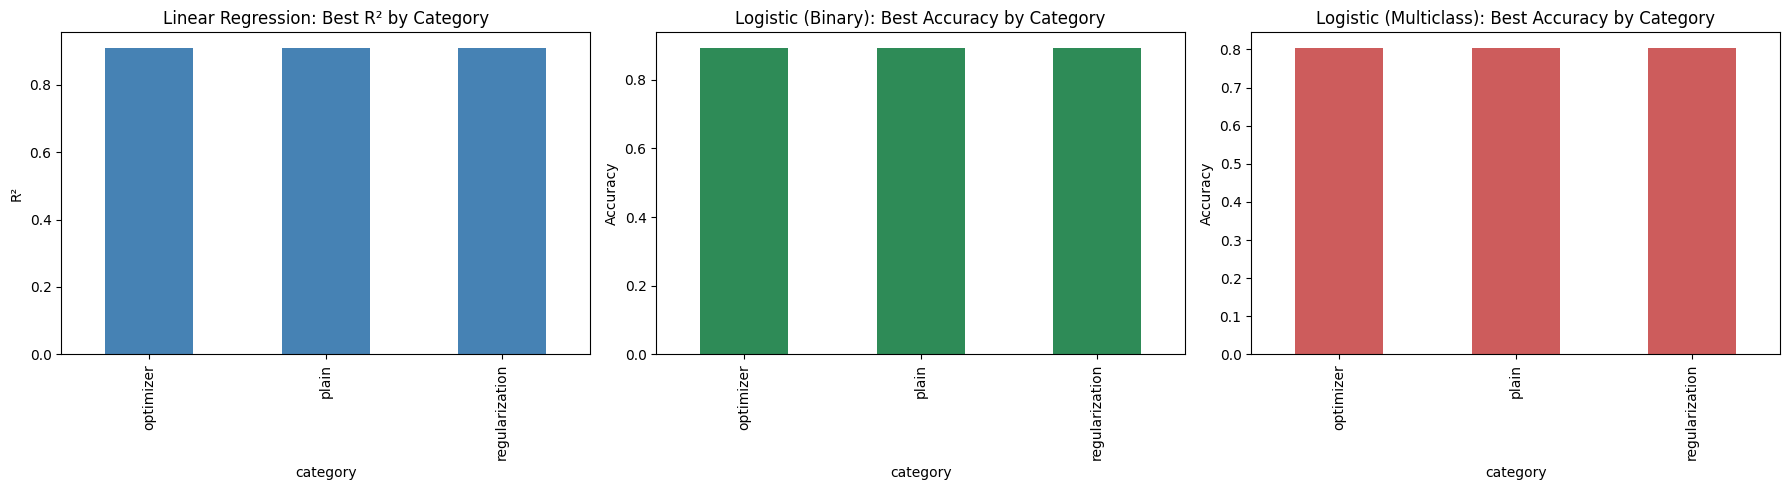

In [19]:
results_df = pd.read_csv(RESULTS_CSV)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear regression: R2 by category
lin = results_df[results_df["task"] == "linear"]
lin.groupby("category")["r2"].max().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Linear Regression: Best R² by Category")
axes[0].set_ylabel("R²")

# Logistic binary: accuracy by category
bin_res = results_df[results_df["task"] == "logistic_binary"]
bin_res.groupby("category")["accuracy"].max().plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Logistic (Binary): Best Accuracy by Category")
axes[1].set_ylabel("Accuracy")

# Logistic multiclass: accuracy by category
multi_res = results_df[results_df["task"] == "logistic_multiclass"]
multi_res.groupby("category")["accuracy"].max().plot(kind="bar", ax=axes[2], color="indianred")
axes[2].set_title("Logistic (Multiclass): Best Accuracy by Category")
axes[2].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

y_linear_train, y_linear_test -> Linear Regression

y_multi_train, y_multi_test -> Multiclass Classification

y_bin_train, y_bin_test -> Binary Classification

X_train_processed,  X_test_processed

In [14]:
lin_model = LinearRegression()
start = time.time()
lin_model.fit(X_train_processed, y_linear_train)
fit_time = time.time() - start
evaluate_regression(lin_model, X_test_processed, y_linear_test)

{'r2': 0.910588710512521, 'mae': 5.318176216703804, 'rmse': 6.115563946889853}

In [ ]:
LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
X_train_processed, y_multi_train, X_test_processed, y_multi_test

In [ ]:
LogisticRegression(C=C, l1_ratio=0.0, solver="saga",
                                max_iter=3000, random_state=RANDOM_STATE),
            X_train_processed, y_tr, X_test_processed, y_te,
            params={"C": C, "l1_ratio": 0.0, "solver": "saga"},
        )

Q. Does Linear Regression use an optimizer?

Answer:

It depends on the implementation. Classical Linear Regression has a closed-form solution using the Normal Equation, so it does not require an optimizer. However, for very large datasets or implementations such as SGDRegressor, the model is trained iteratively using optimization algorithms like Gradient Descent or Stochastic Gradient Descent. In contrast, Logistic Regression has no closed-form solution and always requires an optimization algorithm such as LBFGS, SAGA, or Newton's method.

Q. Do evaluation metrics depend on the model or the problem type?

Answer:

Evaluation metrics depend primarily on the machine learning task, not the algorithm. If the task is regression, models such as Linear Regression, Random Forest Regressor, SVR, and XGBoost Regressor are evaluated using metrics like MAE, RMSE, and R². If the task is classification, models such as Logistic Regression, SVM, Random Forest Classifier, XGBoost Classifier, and Neural Networks are evaluated using metrics like Accuracy, Precision, Recall, F1-score, ROC-AUC, and the Confusion Matrix. Different algorithms solving the same task are compared using the same family of metrics.